<hr>

#### <strong>第一次作品：中央極限定理的實驗</strong>

學號：

姓名：

<hr>

 **<font color=darkgoldenrod>作品目標</font>**

1. 本文透過抽樣分配的模擬實驗來驗證中央極限定理。
1. 模擬不同母體分配下的抽樣分配，觀察其趨近於常態分配的情況。
1. 探討母體分配、樣本數量、抽樣次數對抽樣分配的影響，並分析其收斂速度。
1. 依上述的實驗方式，製作 GUI 介面，讓使用者可以選擇母體分配、樣本數量及抽樣次數，並即時觀察抽樣分配的變化。

<hr>

**<font color=darkgoldenrod>背景理論</font>**

中央極限定理（Central Limit Theorem, CLT）：簡易版的說明如下：

1. Let $X_1, X_2, \cdots, X_n \sim F()$ with expected value given by $\mu$ and finite variance given by $\sigma^{2}$.
1. Let $Y = (X_1 + X_2 + \cdots + X_n) / n$

As $n \longrightarrow \infty, \;\;Y \sim N(a, b/\sqrt{n})$



**<font color=darkgoldenrod>實驗計畫與設定</font>**（以下內容僅供參考，同學們務必以作者的語氣與實際計畫全面改寫）

- 設定母體分配 $F$ 分別為低擴峰分配 $U(0,1)$, 高峽峰分配 $t(3)$, 偏斜分配 $\chi^2(2)$, $\beta(9,2)$ 供實驗選擇。

- 抽樣之樣本數為 $n=5, 10, 30, 50, 100, 300, 500, 1000$。

- 每次實驗共抽樣 $N = 10000$ 次，即得到 $N$ 個平均數 $y_i, i=1,2,\cdots, N$ 作為後續繪圖與分析的依據。
- 驗證中央極限定理趨近常態分配的情況，並觀察母體分配、樣本數量、抽樣次數對抽樣分配的影響，分析其收斂速度。譬如
  - 繪製抽樣分配的直方圖，並與理論常態分配疊圖比較。
  - 繪製抽樣分配的 empirical CDF，觀察其與理論常態分配的吻合程度。
  - 計算抽樣分配的平均數、標準差，並與理論值($\mu, \sigma/\sqrt{n}$)比較。
- 製作 GUI 介面，讓使用者可以選擇母體分配、樣本數量及抽樣次數，並即時觀察抽樣分配的變化。

<hr>

**<font color=darkgoldenrod>預先載入套件與函數</font>**

In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

**<font color=darkgoldenrod>預先載入共用函數（def）</font>**

In [ ]:
# 自訂之共用函數（def）可以放在這裡（函數名稱自取，但必須符合函數目的），譬如：
def ecdf(x):
    # 譬如計算經驗分配函數的程式碼
    return np.sort(x), np.arange(1, len(x)+1) / len(x)

def population(name, size):
    # 譬如產生母體資料的程式碼
    if name == 'normal':
        x =np.random.normal(loc=0, scale=1, size=size)
        
        mu = 0
        sigma = 1
    elif name == 'uniform':
        x = np.random.uniform(low=0, high=1, size=size)
        mu = 0.5
        sigma = np.sqrt(1/12)
    else:
        raise ValueError("Unsupported population type")  

    return x, mu, sigma

**<font color=darkgoldenrod>實驗開始（標題自訂）</font>**

每個實驗之前都必須先說明「要做甚麼」，接著才是「程式碼」及「執行結果」，最後則是對本次實驗結果的說明。如此一系列的實驗，來完整呈現「中央極限定理」的驗證過程。

<hr>

**<font color=darkorange>結論：</font>**
文章一定要有結論（盡量簡短扼要），並且要有「對中央極限定理的驗證結果」的說明。

<hr>

補充示範：以副程式 def 來呈現繪圖功能，並以參數帶入不同的分配與樣本數。

供參考，記得移走。

In [2]:
def RandomNumExp(dist = 'norm', params = (0, 1), n = 1000, bins = 10):
    '''
    說明本程式碼的功能
    dist: 'norm', 't', 'chi2'
    params: 依照dist的不同而有不同的參數需求
        norm: (mean, std)
        t: (df,)
        chi2: (df,)
    n: 產生亂數的個數
    bins: 直方圖的組距數
    '''
    if dist == 'norm':
        xx= np.linspace(-4, 4, 100)
        x = stats.norm.rvs(loc = params[0], scale = params[1], size = n)
        yy = stats.norm.pdf(xx, loc = params[0], scale = params[1])
        Y_ = stats.norm.cdf(xx, loc = params[0], scale = params[1])
    if dist == 't':
        xx= np.linspace(-4, 4, 100)
        x = stats.t.rvs(df = params[0], size = n)
        yy = stats.t.pdf(xx, df = params[0])
        Y_ = stats.t.cdf(xx, df = params[0])
    if dist == 'chi2':
        xx= np.linspace(0, 10, 100)
        x = stats.chi2.rvs(df = params[0], size = n)
        yy = stats.chi2.pdf(xx, df = params[0])
        Y_ = stats.chi2.cdf(xx, df = params[0])
    
    
    fig, ax = plt.subplots(2, 2, figsize = (12, 8))
    # 直方圖
    ax[0,0].hist(x, bins = bins, density = True, alpha = 0.6,\
                  color = 'b', edgecolor = 'y', linewidth = 1)
    
    ax[0,0].plot(xx, yy, color = 'r', linestyle = '--', \
                 linewidth = 3, alpha = 0.8, label = 'real pdf')
    ax[0,0].legend()
    ax[0,0].set_title('Histogram')
    # 盒鬚圖
    ax[0,1].boxplot(x, notch = True, vert = True, labels = ['X'])
    ax[0,1].grid(True)
    ax[0,1].set_title('Boxplot')
    # 機率圖
    stats.probplot(x, dist = "norm", plot = ax[1,0])
    ax[1,0].grid(True)
    ax[1,0].set_title('Probability plot')
    # 經驗累積密度函數
    x = np.sort(x)
    Y = np.arange(1, n+1) / n
    ax[1,1].plot(x, Y, drawstyle = 'steps-pre', label = 'Empirical CDF')
    # Y_ = stats.t.cdf(x, df = df)
    ax[1,1].plot(xx, Y_, color = 'r', linestyle = '--',
        linewidth = 5, alpha = 0.5, label = 'real CDF')
    ax[1,1].legend(), ax[1,1].grid(True)
    ax[1,1].set_title('The Empirical CDF ')
    plt.show()

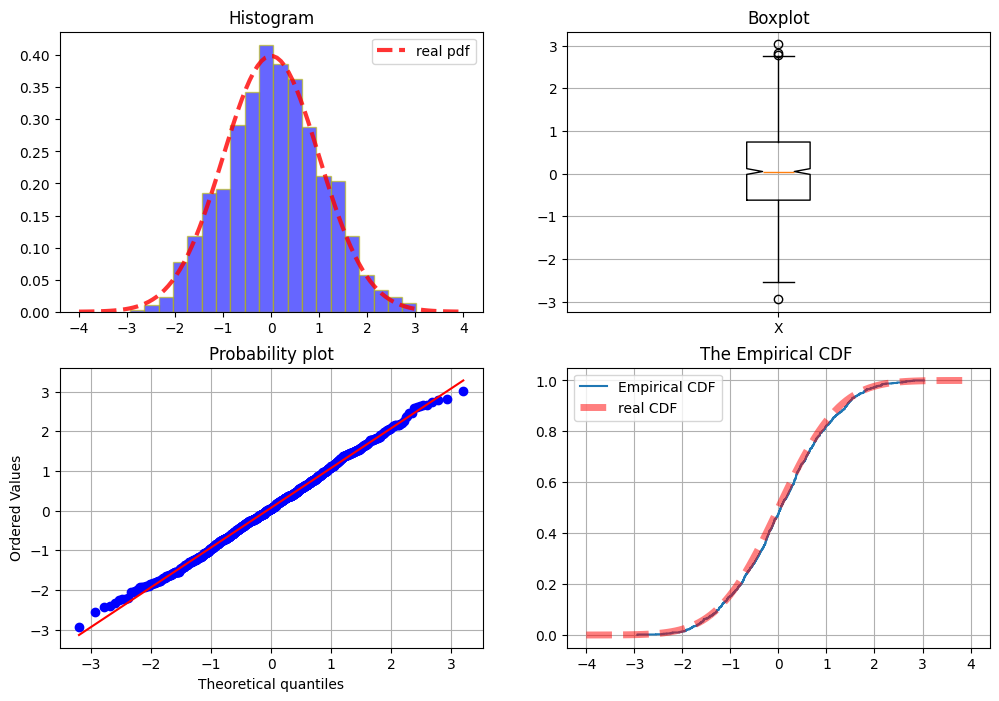

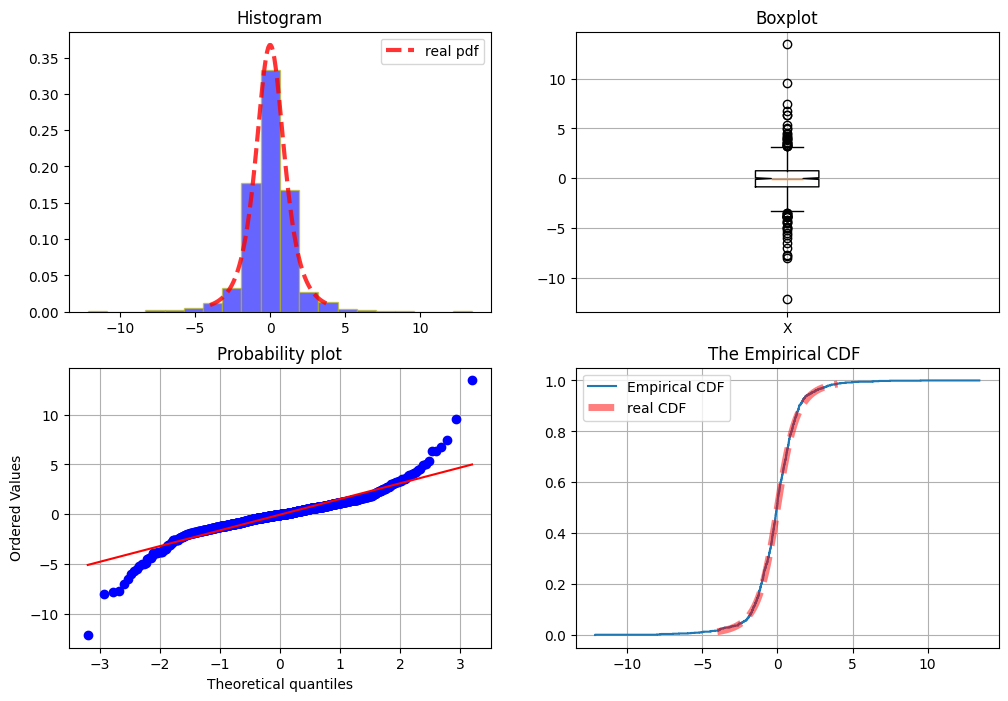

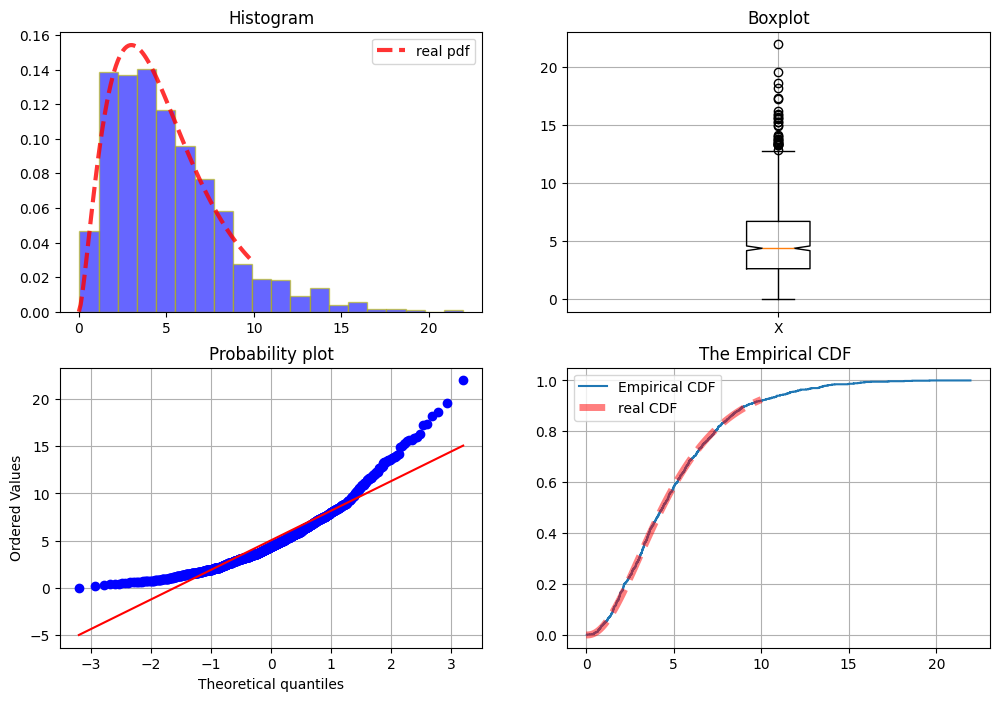

In [3]:
RandomNumExp('norm', (0, 1), 1000, 20)
RandomNumExp('t', (3,), 1000, 20)
RandomNumExp('chi2', (5,), 1000, 20)